# Rolling Feature Dataset Analysis
Analysis of `rolling_feature_engineered_tier_1_games.csv` to evaluate predictive power and data quality.

In [22]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# load data
df = pd.read_csv("../../data/rolling_feature_engineered_tier_1_games.csv")
print(f"Dataset shape: {df.shape}")

Dataset shape: (5539, 84)


## 1. Rolling Feature Distributions
Checking player-level rolling averages.

Found 60 player-level rolling features.


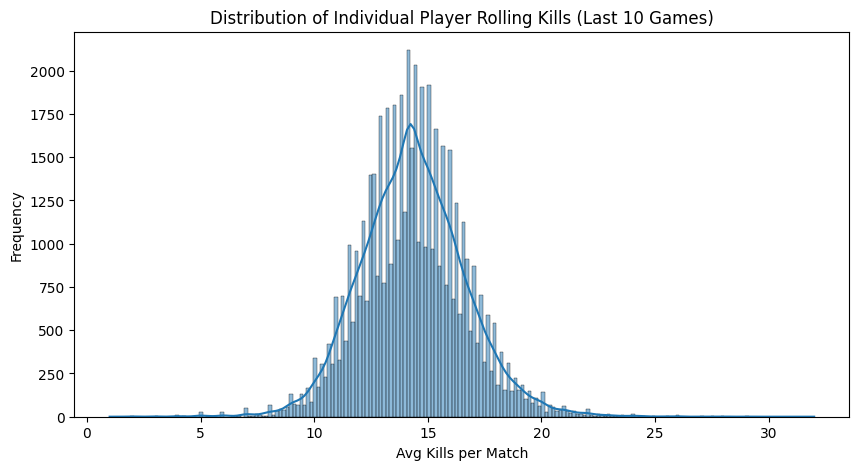

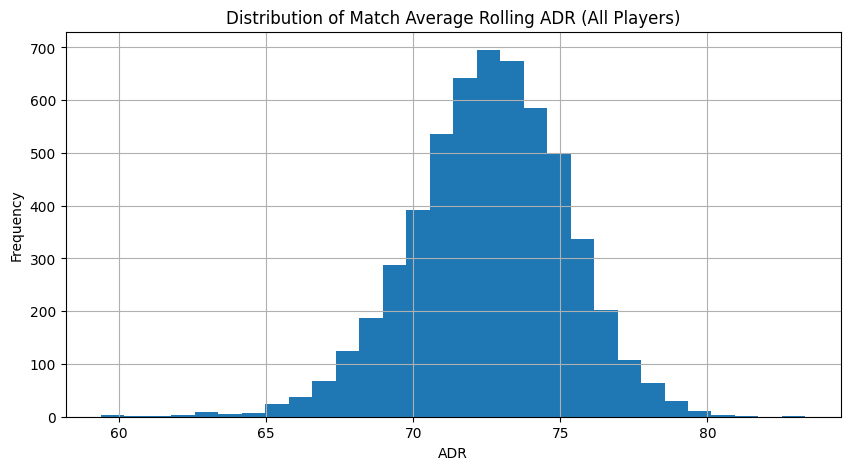

In [23]:
# find all rolling player columns
player_cols = [col for col in df.columns if "previous_10_game" in col and "player" in col]
print(f"Found {len(player_cols)} player-level rolling features.")

# plot distribution of rolling kills
kill_cols = [col for col in player_cols if "average_kills" in col]
kill_data = df[kill_cols].melt()['value']
plt.figure(figsize=(10, 5))
sns.histplot(kill_data, kde=True)
plt.title("Distribution of Individual Player Rolling Kills (Last 10 Games)")
plt.xlabel("Avg Kills per Match")
plt.ylabel("Frequency")
plt.show()

# plot distribution of ADR
adr_cols = [col for col in player_cols if "average_adr" in col]
plt.figure(figsize=(10, 5))
df[adr_cols].mean(axis=1).hist(bins=30)
plt.title("Distribution of Match Average Rolling ADR (All Players)")
plt.xlabel("ADR")
plt.ylabel("Frequency")
plt.show()

## 2. Feature-Target Correlation
Which features predict `team1_win`?

In [24]:
# Ensure only numeric columns are used for correlation
numeric_df = df.select_dtypes(include=[np.number])
correlations = numeric_df.corr()['team1_win'].sort_values(ascending=False)

print("Top 10 Features Correlated with Team 1 Win:")
print(correlations.head(11)) # include target itself

print("\nBottom 10 Features (Correlated with Team 2 Win):")
print(correlations.tail(10))

Top 10 Features Correlated with Team 1 Win:
team1_win                                        1.000000
previous_10_game_team1_player2_average_kast      0.081037
previous_10_game_team1_player3_average_kast      0.080387
previous_10_game_team1_player5_average_kast      0.075585
previous_10_game_team1_player5_average_kddiff    0.072889
previous_10_game_team1_player4_average_kast      0.066250
previous_10_game_team1_player2_average_kddiff    0.063840
previous_10_game_team1_player4_average_kddiff    0.061584
previous_10_game_team1_player1_average_kast      0.057197
team1_previous_10_average_map_score              0.055462
previous_10_game_team1_player4_average_adr       0.052632
Name: team1_win, dtype: float64

Bottom 10 Features (Correlated with Team 2 Win):
previous_10_game_team2_player3_average_kddiff   -0.054407
previous_10_game_team2_player2_average_kast     -0.055866
previous_10_game_team2_player1_average_kddiff   -0.057601
previous_10_game_team2_player5_average_kast     -0.058507
prev

## 3. Team Aggregate Comparison
Calculating 'Delta' stats between teams.

Correlation of ADR Delta with win: 0.1382


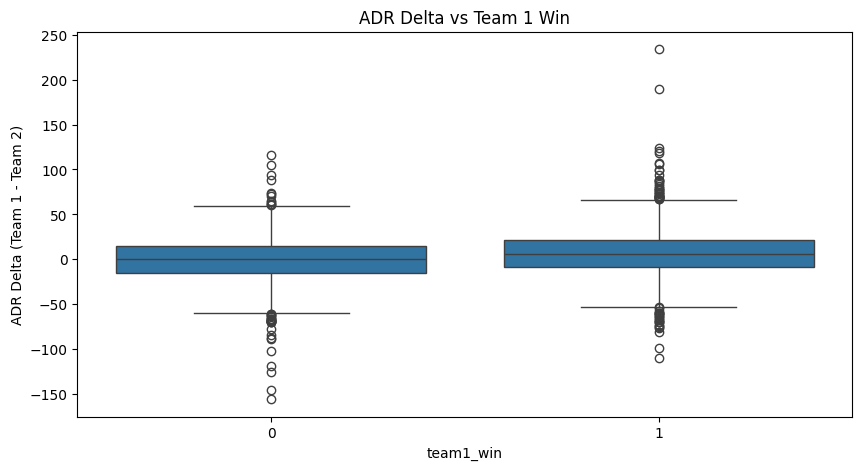

In [25]:
# create aggregate ADR features
t1_adr_cols = [col for col in adr_cols if "team1" in col]
t2_adr_cols = [col for col in adr_cols if "team2" in col]

df['t1_sum_adr'] = df[t1_adr_cols].sum(axis=1)
df['t2_sum_adr'] = df[t2_adr_cols].sum(axis=1)
df['adr_delta'] = df['t1_sum_adr'] - df['t2_sum_adr']

print(f"Correlation of ADR Delta with win: {df['adr_delta'].corr(df['team1_win']):.4f}")

plt.figure(figsize=(10, 5))
sns.boxplot(x='team1_win', y='adr_delta', data=df)
plt.title("ADR Delta vs Team 1 Win")
plt.ylabel("ADR Delta (Team 1 - Team 2)")
plt.show()

## 4. Cold Start Analysis
Checking for matches where players might have low history.

In [26]:
# checking for zeros or very low ADR which might indicate default values
low_history_mask = (df[adr_cols] == 0).any(axis=1)
print(f"Matches with at least one player having 0 rolling ADR: {low_history_mask.sum()}")
print(f"Percentage of dataset: {low_history_mask.mean()*100:.2f}%")

Matches with at least one player having 0 rolling ADR: 0
Percentage of dataset: 0.00%


## 5. Score Validation
Win rate vs historical map score.

Win Rate by Team 1 Historical Map Score (Last 10):
score_bin
(0.976, 5.8]    0.406780
(5.8, 10.6]     0.526546
(10.6, 15.4]    0.563021
(15.4, 20.2]    0.510638
(20.2, 25.0]    0.500000
Name: team1_win, dtype: float64


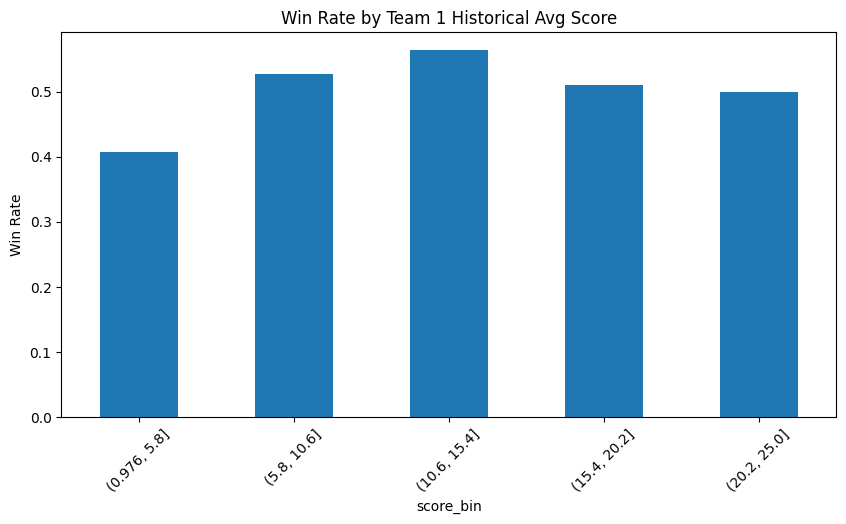

In [27]:
# bin the map score to see win rates
df['score_bin'] = pd.cut(df['team1_previous_10_average_map_score'], bins=5)
win_rate_by_score = df.groupby('score_bin', observed=True)['team1_win'].mean()

print("Win Rate by Team 1 Historical Map Score (Last 10):")
print(win_rate_by_score)

plt.figure(figsize=(10, 5))
win_rate_by_score.plot(kind='bar')
plt.title("Win Rate by Team 1 Historical Avg Score")
plt.ylabel("Win Rate")
plt.xticks(rotation=45)
plt.show()